In [ ]:
# TEXT CLASSIFICATION AND SENTIMENT ANALYSIS

In [ ]:
# Data Cleaning: Remove duplicates, handle missing reviews if any, preprocess text (lowercasing, stopwords removal).

In [1]:
import pandas as pd
df= pd.read_csv("amazonreviews.tsv",sep='\t')  # since it is a tsv file 
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [2]:
df.shape  # it has 10000 rows and 2 columns i.e label and review

(10000, 2)

In [3]:
# Tasks

In [ ]:
# Data Cleaning: Remove duplicates, handle missing reviews if any, preprocess text (lowercasing, stopwords removal).

In [4]:
print(df.duplicated().sum()) # there are no duplicates

0


In [5]:
print(df.isnull().sum()) # there are no missing reviews in the given data

label     0
review    0
dtype: int64


In [6]:
# preprocess text (lowercasing, stopwords removal).

In [7]:
import string  # lowercasting
df['review'] = df['review'].str.lower()
df['review'].head()

0    stuning even for the non-gamer: this sound tra...
1    the best soundtrack ever to anything.: i'm rea...
2    amazing!: this soundtrack is my favorite music...
3    excellent soundtrack: i truly like this soundt...
4    remember, pull your jaw off the floor after he...
Name: review, dtype: object

In [8]:
# removal of stopwords
import nltk
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
df['review'] = df['review'].apply(lambda x: " ".join(word for word in x.split() if word not in stop_words) )
df['review'].head()

0    stuning even non-gamer: sound track beautiful!...
1    best soundtrack ever anything.: reading lot re...
2    amazing!: soundtrack favorite music time, hand...
3    excellent soundtrack: truly like soundtrack en...
4    remember, pull jaw floor hearing it: played ga...
Name: review, dtype: object

In [9]:
# Exploratory Analysis

In [10]:
# Word cloud, sentiment distribution, most common positive/negative words.

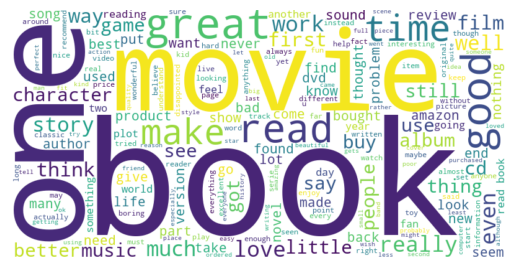

In [11]:
# Word cloud
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud
text = " ".join(df['review'].astype(str))  # joining all strings into one single string to show word cloud
wordcloud = WordCloud(width=800,height=400,background_color='white').generate(text)
wordcloud
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

C:\Users\andeb\AppData\Local\Temp\ipykernel_31520\381408097.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= sentiment_counts.index,y= sentiment_counts.values,palette= "viridis")


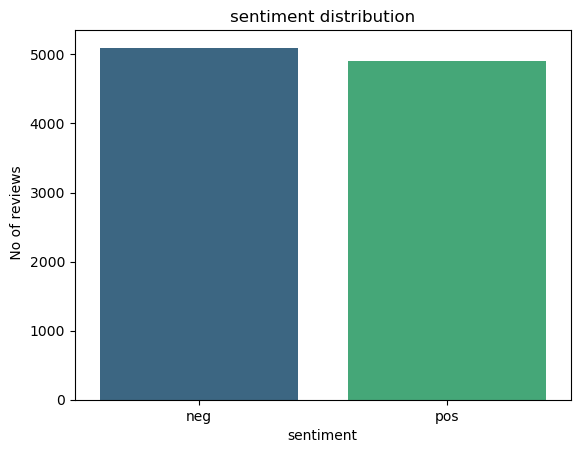

In [12]:
# sentiment distribution
sentiment_counts = df['label'].value_counts() # The negative sentiment is slightly more than the positive sentiment
import matplotlib.pyplot as plt
import seaborn as sns
sns.barplot(x= sentiment_counts.index,y= sentiment_counts.values,palette= "viridis")
plt.title("sentiment distribution")
plt.xlabel("sentiment")
plt.ylabel(" No of reviews")
plt.show()

In [13]:
# most common positive/negative words.
import pandas as pd
import re
from collections import Counter
import nltk
def tokenize_and_clean(text_series):
    words=[]
    for review in text_series:
        review_words = re.findall(r'\b[a-zA-Z]+\b', review.lower())
        review_words = [w for w in review_words if w not in stop_words]
        words.extend(review_words)
    return words

# Separate positive and negative reviews
positive_words = tokenize_and_clean(df[df['label']=='pos']['review'])
negative_words = tokenize_and_clean(df[df['label']=='neg']['review']) 

# Count top 20 words
positive_frequency = Counter(positive_words).most_common(20)
negative_frequency = Counter(negative_words).most_common(20)
print("Most common positive words:",positive_frequency)
print("Most common negative words:",negative_frequency)


Most common positive words: [('book', 3390), ('great', 2135), ('one', 1916), ('good', 1667), ('read', 1605), ('like', 1290), ('movie', 1117), ('would', 956), ('well', 944), ('time', 924), ('love', 911), ('really', 831), ('best', 813), ('get', 805), ('story', 730), ('first', 724), ('much', 664), ('cd', 618), ('music', 576), ('also', 575)]
Most common negative words: [('book', 3277), ('one', 2100), ('like', 1568), ('movie', 1519), ('would', 1465), ('read', 1222), ('good', 1160), ('get', 1151), ('time', 1072), ('even', 910), ('buy', 835), ('really', 783), ('much', 782), ('money', 767), ('bad', 764), ('first', 760), ('better', 677), ('could', 667), ('great', 644), ('story', 640)]


In [ ]:
# Model Development

In [ ]:
# Use NLP techniques (TF-IDF, Word2Vec, or BERT embeddings) with models like Logistic Regression, SVM, or Neural Networks.

In [14]:
df['review']

0       stuning even non-gamer: sound track beautiful!...
1       best soundtrack ever anything.: reading lot re...
2       amazing!: soundtrack favorite music time, hand...
3       excellent soundtrack: truly like soundtrack en...
4       remember, pull jaw floor hearing it: played ga...
                              ...                        
9995    revelation life small town america early 1900s...
9996    great biography interesting journalist: biogra...
9997    interesting subject; poor presentation: hard-p...
9998    buy: box looked used obviously new. tried cont...
9999    beautiful pen fast delivery.: pen shipped prom...
Name: review, Length: 10000, dtype: object

In [15]:
x= df['review']
y= df['label']

In [16]:
# applying tfidfvectorization
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
# fit and transform
X = vectorizer.fit_transform(x)
x_new = X.toarray()
x_new

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [17]:
# form the data frame and give the names
import pandas as pd
df_bow =  pd.DataFrame(x_new,columns= vectorizer.get_feature_names_out())
df_bow

,00,000,001,002,00290,007,0070412901,0072316373,008,00now,...,zzzzzzzzzzzzzzzzzzzzz,zzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzz,ángel,émouvantes,étai,était,étre,éviter,última,única
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Validation: Use train/test split, cross-validation, and metrics like accuracy, F1-score.

In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test =train_test_split(df_bow,y,test_size=0.30,random_state=100) # train_size is 70 and test_size is 30

In [19]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [20]:
y_pred_test= model.predict(x_test) # predicting on test data
y_pred_train= model.predict(x_train)   # predicting on train data

# finding accuracy score for train and test data
from sklearn.metrics import accuracy_score
test_accuracy = accuracy_score(y_pred_test,y_test)
train_accuracy = accuracy_score(y_pred_train,y_train)
print(f"test accuracy score  is {test_accuracy}")  
print(f"train accuracy score  is {train_accuracy}")

test accuracy score  is 0.8583333333333333
train accuracy score  is 0.9431428571428572


In [ ]:
# we got train accuracy as 94 and test accuracy as 86 which is good enough normally with out applying cross validation

In [21]:
from sklearn.metrics import recall_score,precision_score,f1_score
r_score = recall_score(y_test,y_pred_test,pos_label='pos') # recall score tells Out of all actual positive  reviews, how many did the model correctly identify?
print(f"recall score (positive class): {r_score}")

recall score (positive class): 0.8453678474114441


In [22]:
p_score = precision_score(y_test,y_pred_test,pos_label='pos')
print(f"precision score (positive class): {p_score}") # precision score tells Out of all reviews predicted as a certain class (positive or negative), how many were actually correct?

precision score (positive class): 0.862404447533009


In [23]:
f1 = f1_score(y_test,y_pred_test,pos_label='pos')
print(f"f1 score (positive class): {f1}")

f1 score (positive class): 0.8538011695906432


In [24]:
from sklearn.metrics import classification_report # we can get all precision,recall and f1-score
print(classification_report(y_test, y_pred_test))


              precision    recall  f1-score   support

         neg       0.85      0.87      0.86      1532
         pos       0.86      0.85      0.85      1468

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000



In [25]:
# we got train accuracy as 94 and test accuracy as 86 which is good enough
# lets try with cross validation also

In [26]:
# cross validation using shuffle split cross validation
from sklearn.model_selection import ShuffleSplit,cross_validate
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000,solver='saga') # due to huge data saga is better than liblinear as solver

In [27]:
shuffle_split = ShuffleSplit(n_splits=5,test_size=0.3)
cv_results = cross_validate(model,x_train,y_train,cv= shuffle_split,scoring='accuracy',return_train_score= True,n_jobs=-1)
train_scores= cv_results['train_score']
test_scores= cv_results['test_score']
print(f"train accuracy after cross validation is {train_scores}")
print(f"test accuracy after cross validation is {test_scores}")

train accuracy after cross validation is [0.95346939 0.94693878 0.95020408 0.95102041 0.95265306]
test accuracy after cross validation is [0.84       0.86238095 0.84904762 0.85190476 0.84047619]


In [ ]:
# 